In [ ]:
# ============================================================
# 1. Environment Setup
# ============================================================
import os
import re
import sys
import warnings
import subprocess
import importlib.util
from collections import Counter

warnings.filterwarnings("ignore")

# Install only lightweight packages that are actually missing.
# wfdb is installed separately in Part D if necessary.
required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "PIL": "pillow",
    "skimage": "scikit-image",
}

missing = [
    package for module, package in required_packages.items()
    if importlib.util.find_spec(module) is None
]

if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats, signal
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, chi2, VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from PIL import Image
from skimage.feature import hog

print("Python:", sys.version)
print("Environment setup completed successfully.")

Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
Environment setup completed successfully.


# PART A — TABULAR DATA
## Pima Indians Diabetes Dataset

The Pima dataset is used for healthcare-specific tabular cleaning, EDA, statistical hypothesis testing, feature engineering, feature selection, scaling, class-imbalance handling and a simple baseline model.

In [ ]:
# ============================================================
# A1. Data Acquisition
# ============================================================
PIMA_URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
PIMA_LOCAL = "pima-indians-diabetes.data.csv"

PIMA_COLUMNS = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

try:
    pima = pd.read_csv(PIMA_URL, header=None, names=PIMA_COLUMNS)
    print("Pima dataset downloaded successfully.")
except Exception as exc:
    print("Internet download failed:", exc)
    if os.path.exists(PIMA_LOCAL):
        pima = pd.read_csv(PIMA_LOCAL, header=None, names=PIMA_COLUMNS)
        print("Loaded local Pima file:", PIMA_LOCAL)
    else:
        pima = None
        print(
            "Pima dataset is not available. Download the assigned Pima CSV "
            "and place it beside this notebook as 'pima-indians-diabetes.data.csv'."
        )

if pima is not None:
    print("Shape:", pima.shape)
    display(pima.head())

Pima dataset downloaded successfully.
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# ============================================================
# A2. Inspection / Data Quality Audit
# ============================================================
if pima is not None:
    print("Shape:", pima.shape)
    print("\nData types:")
    display(pima.dtypes.to_frame("dtype"))

    print("\nDuplicate rows:", pima.duplicated().sum())

    print("\nLiteral missing values:")
    display(pima.isna().sum().to_frame("Missing"))

    print("\nSummary statistics:")
    display(pima.describe().T)

    print("\nOutcome distribution:")
    display(
        pima["Outcome"]
        .value_counts()
        .sort_index()
        .rename_axis("Outcome")
        .to_frame("Count")
    )

Shape: (768, 9)

Data types:


,dtype
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64



Duplicate rows: 0

Literal missing values:


,Missing
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0



Summary statistics:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00



Outcome distribution:


,Count
Outcome,
0,500
1,268


In [ ]:
# ============================================================
# A3. Cleaning: Encoded Missingness + Implausible Values
# ============================================================
if pima is not None:
    pima_clean = pima.copy()

    # In the Pima dataset, zero is conventionally treated as
    # missing for these physiological measurements.
    zero_missing_cols = [
        "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"
    ]
    pima_clean[zero_missing_cols] = (
        pima_clean[zero_missing_cols].replace(0, np.nan)
    )

    # Broad plausibility checks. These are deliberately conservative.
    clinical_ranges = {
        "Glucose": (20, 500),
        "BloodPressure": (20, 200),
        "SkinThickness": (1, 100),
        "Insulin": (1, 1000),
        "BMI": (10, 80),
        "Age": (10, 120),
        "Pregnancies": (0, 20),
        "DiabetesPedigreeFunction": (0, 5),
    }

    invalid_counts = {}
    for col, (low, high) in clinical_ranges.items():
        invalid = (pima_clean[col] < low) | (pima_clean[col] > high)
        invalid_counts[col] = int(invalid.sum())
        pima_clean.loc[invalid, col] = np.nan

    print("Invalid values replaced with NaN:")
    display(pd.Series(invalid_counts, name="Invalid count"))

    print("Missing values after healthcare-specific cleaning:")
    display(pima_clean.isna().sum().to_frame("Missing"))

    # Remove exact duplicate observations.
    before = len(pima_clean)
    pima_clean = pima_clean.drop_duplicates().reset_index(drop=True)
    print("Duplicate rows removed:", before - len(pima_clean))

    # Median imputation.
    # In a real ML pipeline, fit imputation statistics on TRAINING DATA ONLY.
    impute_cols = zero_missing_cols + [
        "Age", "Pregnancies", "DiabetesPedigreeFunction"
    ]
    for col in impute_cols:
        pima_clean[col] = pima_clean[col].fillna(pima_clean[col].median())

    print("Remaining missing values:", int(pima_clean.isna().sum().sum()))
    display(pima_clean.describe().T)

Invalid values replaced with NaN:


,Invalid count
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
Age,0
Pregnancies,0
DiabetesPedigreeFunction,0


Missing values after healthcare-specific cleaning:


,Missing
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Duplicate rows removed: 0
Remaining missing values: 0


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.656250,30.438286,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.386719,12.096642,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.108073,8.791221,7.000,25.00000,29.0000,32.00000,99.00
Insulin,768.0,140.671875,86.383060,14.000,121.50000,125.0000,127.25000,846.00
BMI,768.0,32.455208,6.875177,18.200,27.50000,32.3000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


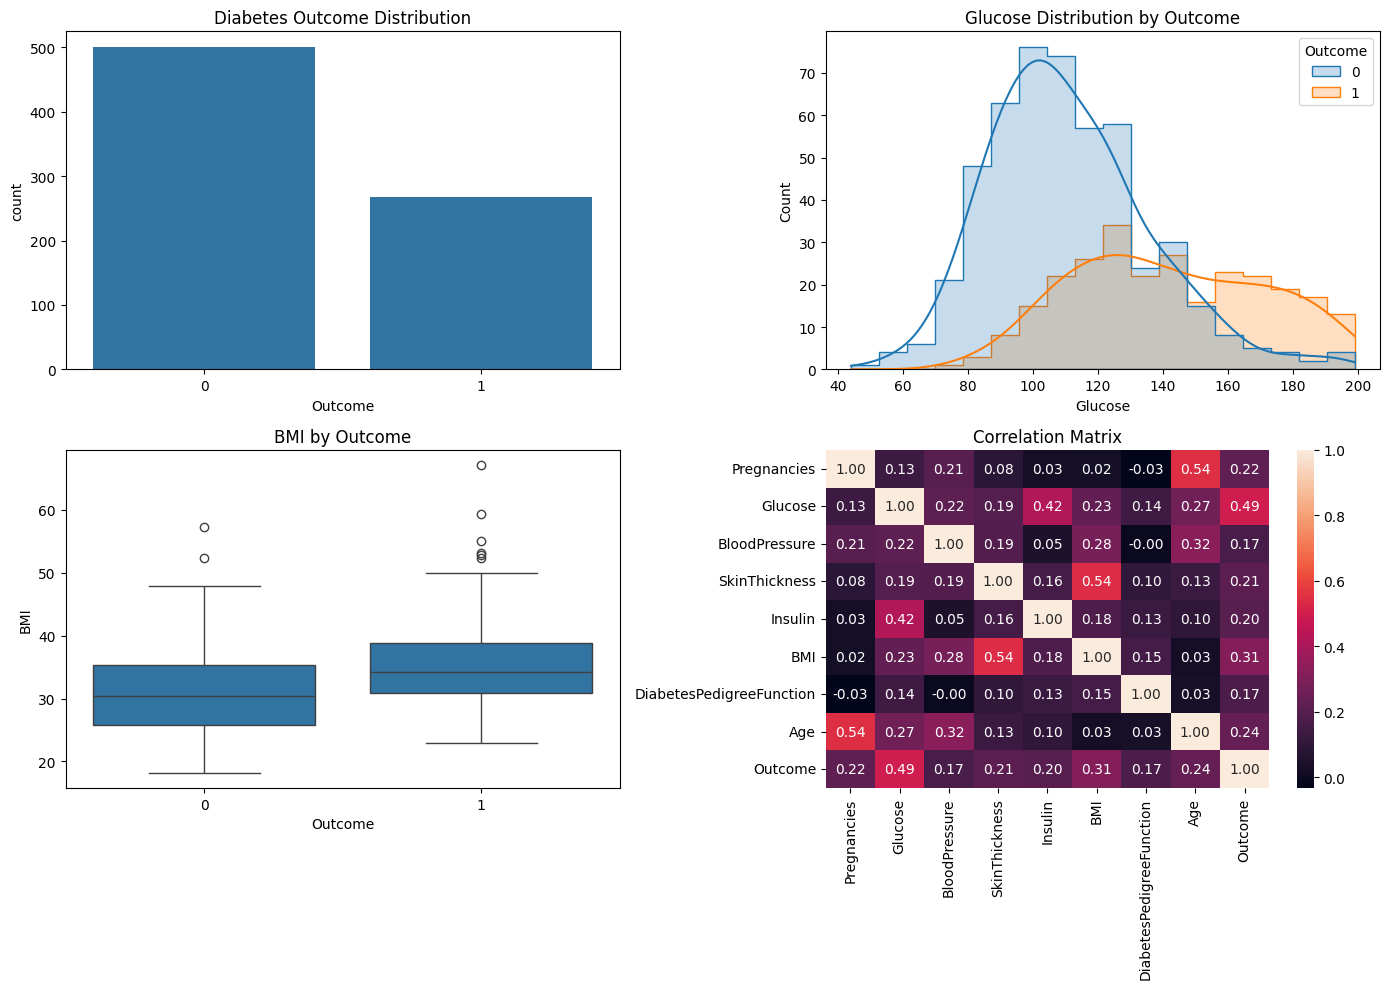

In [ ]:
# ============================================================
# A4. EDA
# ============================================================
if pima is not None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    sns.countplot(data=pima_clean, x="Outcome", ax=axes[0, 0])
    axes[0, 0].set_title("Diabetes Outcome Distribution")

    sns.histplot(
        data=pima_clean,
        x="Glucose",
        hue="Outcome",
        kde=True,
        element="step",
        ax=axes[0, 1]
    )
    axes[0, 1].set_title("Glucose Distribution by Outcome")

    sns.boxplot(
        data=pima_clean,
        x="Outcome",
        y="BMI",
        ax=axes[1, 0]
    )
    axes[1, 0].set_title("BMI by Outcome")

    corr = pima_clean.corr(numeric_only=True)
    sns.heatmap(corr, annot=True, fmt=".2f", ax=axes[1, 1])
    axes[1, 1].set_title("Correlation Matrix")

    plt.tight_layout()
    plt.show()

### A5. Statistical Tests

The assignment requires:
1. **Hypothesis test** — independent two-sample t-test.
2. **Chi-square test** — association between categorical variables.
3. **ANOVA** — comparison of mean glucose across BMI categories.

For each test, the null and alternative hypotheses are stated and the p-value is interpreted using α = 0.05.

In [ ]:
# ============================================================
# A5.1 Hypothesis Test — Independent Two-Sample t-test
# ============================================================
if pima is not None:
    alpha = 0.05

    group_0 = pima_clean.loc[pima_clean["Outcome"] == 0, "Glucose"]
    group_1 = pima_clean.loc[pima_clean["Outcome"] == 1, "Glucose"]

    # Welch's t-test is used because equal variances are not assumed.
    t_stat, p_value = stats.ttest_ind(
        group_0, group_1, equal_var=False
    )

    print("H0: Mean glucose is equal in the two outcome groups.")
    print("H1: Mean glucose differs between the two outcome groups.")
    print(f"t-statistic = {t_stat:.4f}")
    print(f"p-value     = {p_value:.6g}")

    if p_value < alpha:
        print("Decision: Reject H0.")
    else:
        print("Decision: Fail to reject H0.")

H0: Mean glucose is equal in the two outcome groups.
H1: Mean glucose differs between the two outcome groups.
t-statistic = -14.8527
p-value     = 3.54215e-41
Decision: Reject H0.


In [ ]:
# ============================================================
# A5.2 Chi-square Test — Age Group vs Outcome
# ============================================================
if pima is not None:
    pima_clean["AgeGroup"] = pd.cut(
        pima_clean["Age"],
        bins=[0, 30, 45, np.inf],
        labels=["<=30", "31-45", ">45"],
        include_lowest=True
    )

    contingency = pd.crosstab(
        pima_clean["AgeGroup"],
        pima_clean["Outcome"]
    )

    chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(contingency)

    print("H0: Age group and diabetes outcome are independent.")
    print("H1: Age group and diabetes outcome are associated.")
    display(contingency)
    print(f"Chi-square statistic = {chi2_stat:.4f}")
    print(f"Degrees of freedom  = {dof}")
    print(f"p-value              = {chi2_p:.6g}")

    if chi2_p < 0.05:
        print("Decision: Reject H0.")
    else:
        print("Decision: Fail to reject H0.")

H0: Age group and diabetes outcome are independent.
H1: Age group and diabetes outcome are associated.


Outcome,0,1
AgeGroup,,
<=30,327,90
31-45,113,120
>45,60,58


Chi-square statistic = 71.3717
Degrees of freedom  = 2
p-value              = 3.17567e-16
Decision: Reject H0.


In [ ]:
# ============================================================
# A5.3 ANOVA — Glucose Across BMI Categories
# ============================================================
if pima is not None:
    pima_clean["BMICategory"] = pd.cut(
        pima_clean["BMI"],
        bins=[0, 18.5, 25, 30, np.inf],
        labels=["Underweight", "Normal", "Overweight", "Obese"],
        include_lowest=True
    )

    grouped = [
        group["Glucose"].dropna().to_numpy()
        for _, group in pima_clean.groupby(
            "BMICategory", observed=False
        )
    ]
    grouped = [g for g in grouped if len(g) > 0]

    if len(grouped) >= 2:
        anova_stat, anova_p = stats.f_oneway(*grouped)

        print("H0: Mean glucose is equal across BMI categories.")
        print("H1: At least one BMI category has a different mean glucose.")
        print(f"F-statistic = {anova_stat:.4f}")
        print(f"p-value     = {anova_p:.6g}")

        if anova_p < 0.05:
            print("Decision: Reject H0.")
        else:
            print("Decision: Fail to reject H0.")
    else:
        print("ANOVA could not be performed because fewer than two groups exist.")

H0: Mean glucose is equal across BMI categories.
H1: At least one BMI category has a different mean glucose.
F-statistic = 13.2542
p-value     = 1.92494e-08
Decision: Reject H0.


In [ ]:
# ============================================================
# A6. Feature Engineering
# ============================================================
if pima is not None:
    pima_fe = pima_clean.drop(
        columns=["AgeGroup", "BMICategory"], errors="ignore"
    ).copy()

    pima_fe["Glucose_BMI_Ratio"] = (
        pima_fe["Glucose"] / pima_fe["BMI"].replace(0, np.nan)
    )
    pima_fe["Age_Glucose_Interaction"] = (
        pima_fe["Age"] * pima_fe["Glucose"]
    )
    pima_fe["BMI_Obese_Flag"] = (
        pima_fe["BMI"] >= 30
    ).astype(int)
    pima_fe["High_Glucose_Flag"] = (
        pima_fe["Glucose"] >= 126
    ).astype(int)

    pima_fe = pima_fe.replace(
        [np.inf, -np.inf], np.nan
    ).fillna(0)

    print("Engineered features created:")
    print([
        "Glucose_BMI_Ratio",
        "Age_Glucose_Interaction",
        "BMI_Obese_Flag",
        "High_Glucose_Flag"
    ])
    display(pima_fe.head())

Engineered features created:
['Glucose_BMI_Ratio', 'Age_Glucose_Interaction', 'BMI_Obese_Flag', 'High_Glucose_Flag']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_BMI_Ratio,Age_Glucose_Interaction,BMI_Obese_Flag,High_Glucose_Flag
0,6.0,148.0,72.0,35.0,125.0,33.6,0.627,50.0,1,4.404762,7400.0,1,1
1,1.0,85.0,66.0,29.0,125.0,26.6,0.351,31.0,0,3.195489,2635.0,0,0
2,8.0,183.0,64.0,29.0,125.0,23.3,0.672,32.0,1,7.854077,5856.0,0,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0,3.167260,1869.0,0,0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1,3.178654,4521.0,1,1


In [ ]:
# ============================================================
# A7. Feature Selection + Scaling + Model-Ready Format
# ============================================================
if pima is not None:
    X = pima_fe.drop(columns=["Outcome"])
    y = pima_fe["Outcome"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    # Scaling is fitted only on training data.
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Feature selection is also fitted only on training data.
    k = min(8, X_train_scaled.shape[1])
    selector = SelectKBest(score_func=f_classif, k=k)

    X_train_selected = selector.fit_transform(
        X_train_scaled, y_train
    )
    X_test_selected = selector.transform(X_test_scaled)

    selected_features = X.columns[selector.get_support()]

    print("Selected features:")
    print(list(selected_features))
    print("Model-ready train shape:", X_train_selected.shape)
    print("Model-ready test shape :", X_test_selected.shape)

    classes = np.unique(y_train)
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train
    )
    class_weights = dict(zip(classes, weights))
    print("Balanced class weights:", class_weights)

Selected features:
['Glucose', 'SkinThickness', 'Insulin', 'BMI', 'Age', 'Age_Glucose_Interaction', 'BMI_Obese_Flag', 'High_Glucose_Flag']
Model-ready train shape: (614, 8)
Model-ready test shape : (154, 8)
Balanced class weights: {np.int64(0): np.float64(0.7675), np.int64(1): np.float64(1.4345794392523366)}


Accuracy: 0.7597
ROC-AUC : 0.8155

Classification Report:
              precision    recall  f1-score   support

           0     0.8182    0.8100    0.8141       100
           1     0.6545    0.6667    0.6606        54

    accuracy                         0.7597       154
   macro avg     0.7364    0.7383    0.7373       154
weighted avg     0.7608    0.7597    0.7602       154



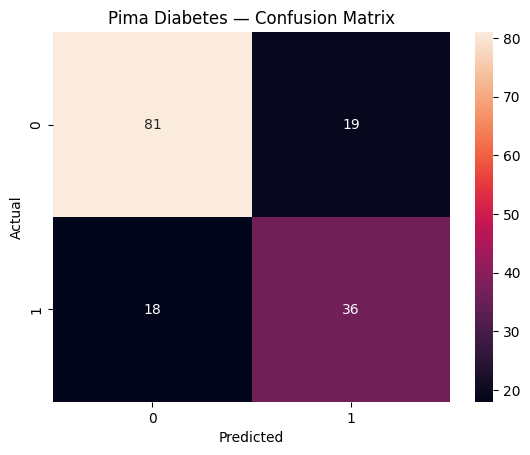

In [ ]:
# ============================================================
# A8. Baseline Model + Evaluation
# ============================================================
if pima is not None:
    clf = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight=class_weights
    )
    clf.fit(X_train_selected, y_train)

    pred = clf.predict(X_test_selected)
    prob = clf.predict_proba(X_test_selected)[:, 1]

    print("Accuracy:", round(accuracy_score(y_test, pred), 4))
    print("ROC-AUC :", round(roc_auc_score(y_test, prob), 4))
    print("\nClassification Report:")
    print(classification_report(y_test, pred, digits=4))

    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title("Pima Diabetes — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# PART B — TEXTUAL DATA
## MTSamples Medical Transcriptions

The MTSamples corpus contains medical transcription samples and specialty/category information. The notebook performs inspection, PHI/identifier masking, text normalization, tokenization, EDA, TF-IDF feature engineering, chi-square feature selection and model-ready token sequences.

**Privacy note:** Regex/NER masking is a preprocessing demonstration, not a guarantee of complete clinical de-identification.

In [ ]:
# ============================================================
# B1. Data Acquisition
# ============================================================
MTSAMPLES_URL = (
    "https://raw.githubusercontent.com/salgadev/medical-nlp/"
    "master/data/mtsamples.csv"
)
MTSAMPLES_LOCAL = "mtsamples.csv"

try:
    mts = pd.read_csv(MTSAMPLES_URL)
    print("MTSamples downloaded successfully.")
except Exception as exc:
    print("MTSamples download failed:", exc)
    if os.path.exists(MTSAMPLES_LOCAL):
        mts = pd.read_csv(MTSAMPLES_LOCAL)
        print("Loaded local MTSamples file.")
    else:
        mts = None
        print(
            "Place 'mtsamples.csv' beside this notebook or update "
            "MTSAMPLES_URL/MTSAMPLES_LOCAL."
        )

if mts is not None:
    print("Shape:", mts.shape)
    print("Columns:", list(mts.columns))
    display(mts.head())

MTSamples downloaded successfully.
Shape: (4999, 6)
Columns: ['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [ ]:
# ============================================================
# B2. Inspection + Text/Label Field Identification
# ============================================================
if mts is not None:
    print("Missing values:")
    display(mts.isna().sum().sort_values(ascending=False).to_frame("Missing"))

    print("Duplicate rows:", mts.duplicated().sum())

    # Identify transcription field robustly.
    exact_text = [
        c for c in mts.columns
        if c.lower() in {"transcription", "text", "report", "description"}
    ]

    if exact_text:
        TEXT_COL = exact_text[0]
    else:
        object_cols = list(mts.select_dtypes(include="object").columns)
        if not object_cols:
            raise ValueError("No text column could be identified in MTSamples.")
        TEXT_COL = max(
            object_cols,
            key=lambda c: mts[c].fillna("").astype(str).str.len().mean()
        )

    label_candidates = [
        c for c in mts.columns
        if "special" in c.lower()
        or "category" in c.lower()
        or "label" in c.lower()
    ]
    LABEL_COL = label_candidates[0] if label_candidates else None

    mts[TEXT_COL] = mts[TEXT_COL].fillna("").astype(str)

    print("Text column:", TEXT_COL)
    print("Label column:", LABEL_COL)
    display(mts[TEXT_COL].str.len().describe().to_frame("Character count"))

Missing values:


,Missing
keywords,1068
transcription,33
description,0
Unnamed: 0,0
sample_name,0
medical_specialty,0


Duplicate rows: 0
Text column: description
Label column: medical_specialty


,Character count
count,4999.000000
mean,132.440688
std,80.360019
min,1.000000
25%,68.500000
50%,117.000000
75%,181.000000
max,492.000000


In [ ]:
# ============================================================
# B3. PHI / Identifier Cleaning
# ============================================================
if mts is not None:
    def mask_phi(text):
        text = str(text)

        patterns = [
            (r"\b[A-Z0-9._%+-]+@[A-Z0-9.-]+\.[A-Z]{2,}\b", "[EMAIL]"),
            (r"\b(?:\+?\d[\d\s().-]{7,}\d)\b", "[PHONE]"),
            (r"\b\d{3}-\d{2}-\d{4}\b", "[SSN]"),
            (
                r"\b(?:MRN|Medical Record Number|Record Number)"
                r"\s*[:#-]?\s*[A-Z0-9-]+\b",
                "[MRN]"
            ),
            (
                r"\b(?:DOB|Date of Birth)"
                r"\s*[:#-]?\s*\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b",
                "[DOB]"
            ),
            (r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b", "[DATE]"),
            (r"https?://\S+|www\.\S+", "[URL]"),
            (
                r"\b(?:account|policy|claim)"
                r"\s*(?:number|no\.?|#)\s*[:#-]?\s*[A-Z0-9-]+\b",
                "[IDENTIFIER]"
            ),
        ]

        for pattern, replacement in patterns:
            text = re.sub(
                pattern, replacement, text, flags=re.IGNORECASE
            )

        text = re.sub(r"\s+", " ", text).strip()
        return text

    mts["CleanText"] = mts[TEXT_COL].apply(mask_phi)

    print("PHI/identifier masking applied.")
    display(mts[[TEXT_COL, "CleanText"]].head(3))

PHI/identifier masking applied.


,description,CleanText
0,A 23-year-old white female presents with comp...,A 23-year-old white female presents with compl...
1,Consult for laparoscopic gastric bypass.,Consult for laparoscopic gastric bypass.
2,Consult for laparoscopic gastric bypass.,Consult for laparoscopic gastric bypass.


In [ ]:
# ============================================================
# B4. Text Normalization and Tokenization
# ============================================================
if mts is not None:
    # Regex tokenization is used instead of NLTK so the notebook
    # does not depend on downloadable punkt/punkt_tab resources.
    def normalize_text(text):
        text = str(text).lower()
        text = re.sub(r"[^a-z0-9\[\]_-]+", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

    def tokenize(text):
        return re.findall(r"\[[a-z_]+\]|[a-z0-9_-]+", text)

    stopwords = {
        "a", "an", "and", "are", "as", "at", "be", "by", "for",
        "from", "has", "he", "in", "is", "it", "of", "on", "or",
        "that", "the", "this", "to", "was", "were", "with", "we",
        "you", "your"
    }

    mts["NormalizedText"] = mts["CleanText"].apply(normalize_text)
    mts["Tokens"] = mts["NormalizedText"].apply(tokenize)
    mts["FilteredTokens"] = mts["Tokens"].apply(
        lambda tokens: [
            token for token in tokens
            if token not in stopwords
        ]
    )

    display(
        mts[["NormalizedText", "Tokens", "FilteredTokens"]].head(3)
    )

,NormalizedText,Tokens,FilteredTokens
0,a 23-year-old white female presents with compl...,"[a, 23-year-old, white, female, presents, with...","[23-year-old, white, female, presents, complai..."
1,consult for laparoscopic gastric bypass,"[consult, for, laparoscopic, gastric, bypass]","[consult, laparoscopic, gastric, bypass]"
2,consult for laparoscopic gastric bypass,"[consult, for, laparoscopic, gastric, bypass]","[consult, laparoscopic, gastric, bypass]"


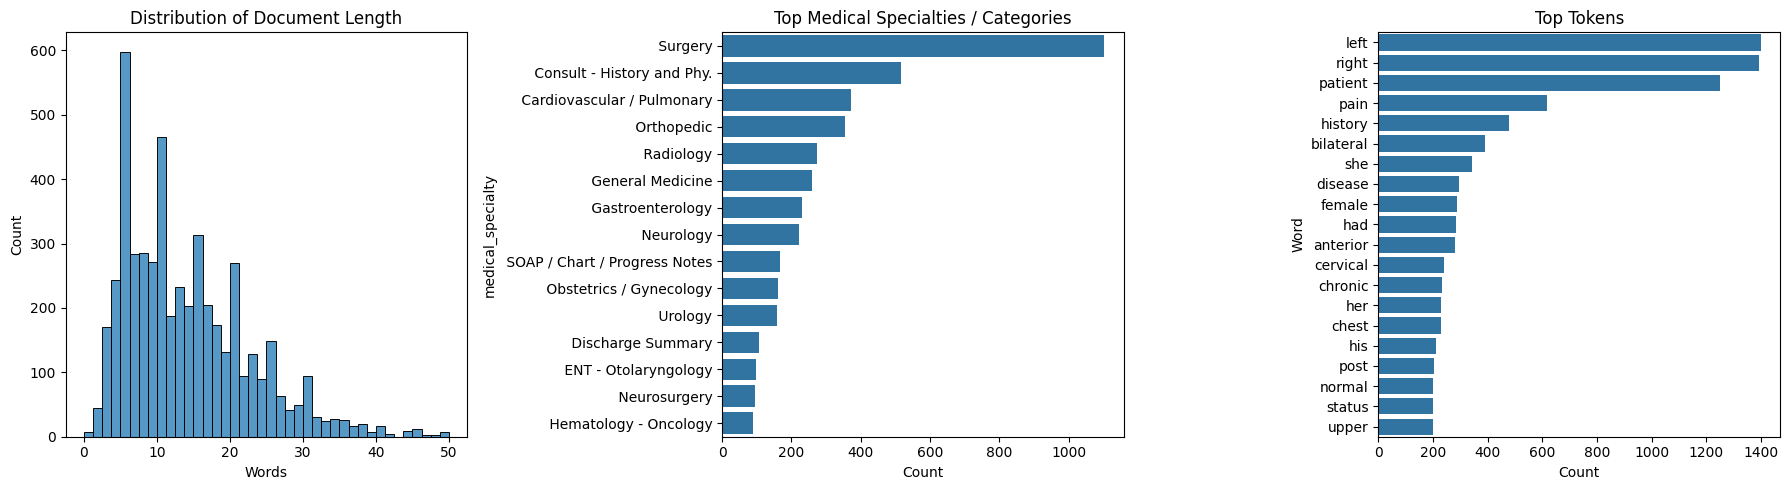

,WordCount,CharCount
count,4999.000000,4999.000000
mean,13.958792,130.494699
std,8.586559,79.635187
min,0.000000,0.000000
25%,7.000000,67.000000
50%,12.000000,116.000000
75%,19.000000,179.000000
max,50.000000,491.000000


In [ ]:
# ============================================================
# B5. Text EDA
# ============================================================
if mts is not None:
    mts["WordCount"] = mts["FilteredTokens"].str.len()
    mts["CharCount"] = mts["CleanText"].str.len()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.histplot(mts["WordCount"], bins=40, ax=axes[0])
    axes[0].set_title("Distribution of Document Length")
    axes[0].set_xlabel("Words")

    if LABEL_COL is not None:
        top_labels = mts[LABEL_COL].fillna("UNKNOWN").value_counts().head(15)
        sns.barplot(
            x=top_labels.values,
            y=top_labels.index,
            ax=axes[1]
        )
        axes[1].set_title("Top Medical Specialties / Categories")
        axes[1].set_xlabel("Count")
    else:
        axes[1].text(
            0.5, 0.5,
            "No label column detected",
            ha="center", va="center"
        )
        axes[1].set_axis_off()

    word_counts = Counter(
        token
        for tokens in mts["FilteredTokens"]
        for token in tokens
        if len(token) > 2 and not token.startswith("[")
    )
    top_words = pd.DataFrame(
        word_counts.most_common(20),
        columns=["Word", "Count"]
    )

    sns.barplot(
        data=top_words,
        x="Count",
        y="Word",
        ax=axes[2]
    )
    axes[2].set_title("Top Tokens")

    plt.tight_layout()
    plt.show()

    display(mts[["WordCount", "CharCount"]].describe())

In [ ]:
# ============================================================
# B6. Feature Engineering: TF-IDF + Chi-square Selection
# ============================================================
if mts is not None:
    tfidf = TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )

    X_text = tfidf.fit_transform(mts["NormalizedText"])
    print("TF-IDF matrix shape:", X_text.shape)

    if LABEL_COL is not None:
        labels = mts[LABEL_COL].fillna("UNKNOWN").astype(str)

        if labels.nunique() >= 2:
            le_text = LabelEncoder()
            y_text = le_text.fit_transform(labels)

            k = min(500, X_text.shape[1])
            text_selector = SelectKBest(
                score_func=chi2,
                k=k
            )
            X_text_selected = text_selector.fit_transform(
                X_text, y_text
            )

            selected_terms = np.array(
                tfidf.get_feature_names_out()
            )[text_selector.get_support()]

            print(
                "Selected TF-IDF matrix shape:",
                X_text_selected.shape
            )
            print("First 30 selected terms:")
            print(selected_terms[:30])
        else:
            X_text_selected = X_text
            print("Only one label class found; supervised selection skipped.")
    else:
        X_text_selected = X_text
        print("No label detected; supervised selection skipped.")

TF-IDF matrix shape: (4999, 5000)
Selected TF-IDF matrix shape: (4999, 500)
First 30 selected terms:
['12 year' '17' '18 gauge' '41' '41 year' 'abdomen' 'abdomen and'
 'abdominal hysterectomy' 'acne' 'actinic' 'adenocarcinoma'
 'adenoidectomy' 'advanced' 'allergic' 'allergies' 'an example'
 'an overnight' 'and adenoidectomy' 'and advanced' 'and curettage'
 'and is' 'and pelvis' 'and records' 'angle' 'ankle' 'answers'
 'answers and' 'antecolic' 'antecolic antegastric' 'antegastric']


In [ ]:
# ============================================================
# B7. Model-Ready Token Sequences
# ============================================================
if mts is not None:
    MAX_VOCAB = 10000
    MAX_LEN = 300

    counter = Counter(
        token
        for tokens in mts["Tokens"]
        for token in tokens
    )

    vocab = {"<PAD>": 0, "<OOV>": 1}
    for word, _ in counter.most_common(MAX_VOCAB - 2):
        vocab[word] = len(vocab)

    def text_to_ids(tokens):
        return [vocab.get(token, 1) for token in tokens]

    sequences = mts["Tokens"].apply(text_to_ids).tolist()

    X_text_padded = np.zeros(
        (len(sequences), MAX_LEN),
        dtype=np.int32
    )

    for i, sequence in enumerate(sequences):
        sequence = sequence[:MAX_LEN]
        X_text_padded[i, :len(sequence)] = sequence

    print("Vocabulary size:", len(vocab))
    print("Model-ready sequence shape:", X_text_padded.shape)
    print("Example sequence IDs:", X_text_padded[0][:30])

Vocabulary size: 5893
Model-ready sequence shape: (4999, 300)
Example sequence IDs: [   6 3086  189   25   76    5  377    3  968    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]


### B8. Conservative Text Augmentation

Clinical text augmentation must not change medical meaning. Instead of uncontrolled synonym replacement, the lab uses a very small amount of random deletion of non-essential tokens. PHI placeholders and short clinical tokens are retained.

In [ ]:
# ============================================================
# B8. Conservative Text Augmentation
# ============================================================
if mts is not None:
    rng = np.random.default_rng(42)

    def conservative_text_augmentation(tokens, keep_prob=0.95):
        augmented = []
        for token in tokens:
            if token.startswith("[") or len(token) <= 3:
                augmented.append(token)
            elif rng.random() < keep_prob:
                augmented.append(token)
        return " ".join(augmented)

    mts["AugmentedText"] = mts["FilteredTokens"].apply(
        conservative_text_augmentation
    )

    display(
        mts[["NormalizedText", "AugmentedText"]].head(3)
    )

,NormalizedText,AugmentedText
0,a 23-year-old white female presents with compl...,23-year-old white female presents complaint
1,consult for laparoscopic gastric bypass,consult laparoscopic gastric bypass
2,consult for laparoscopic gastric bypass,consult laparoscopic gastric bypass


# PART C — IMAGE DATA
## Chest X-Ray Images (Pneumonia)

The assigned dataset contains chest X-ray images in **NORMAL** and **PNEUMONIA** classes. The dataset is commonly organized into train/test/validation folders and contains images with varying resolutions. citeturn0search0turn0search14

This section performs image inventory, EDA, metadata stripping, resizing/normalization, model-ready tensor creation, HOG feature extraction, class-imbalance analysis and augmentation.

In [ ]:
# ============================================================
# C1. Dataset Acquisition / Path Configuration
# ============================================================
IMAGE_ROOT = "chest_xray"

# If the dataset is already extracted, the notebook uses it directly.
# Otherwise it attempts a public KaggleHub download.
if not os.path.exists(IMAGE_ROOT):
    try:
        if importlib.util.find_spec("kagglehub") is None:
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", "-q", "kagglehub"]
            )
        import kagglehub

        IMAGE_ROOT = kagglehub.dataset_download(
            "paultimothymooney/chest-xray-pneumonia"
        )
        print("Dataset downloaded to:", IMAGE_ROOT)
    except Exception as exc:
        print("Automatic image download unavailable:", exc)
        print(
            "Download/extract the assigned Chest X-Ray dataset and set "
            "IMAGE_ROOT to its folder."
        )

image_available = os.path.exists(IMAGE_ROOT)

if image_available:
    print("Image root:", IMAGE_ROOT)
else:
    print("Image section will remain safely skipped until IMAGE_ROOT exists.")

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset downloaded to: /kaggle/input/chest-xray-pneumonia
Image root: /kaggle/input/chest-xray-pneumonia


Total images: 17568


,Count
Label,
PNEUMONIA,12819
NORMAL,4749


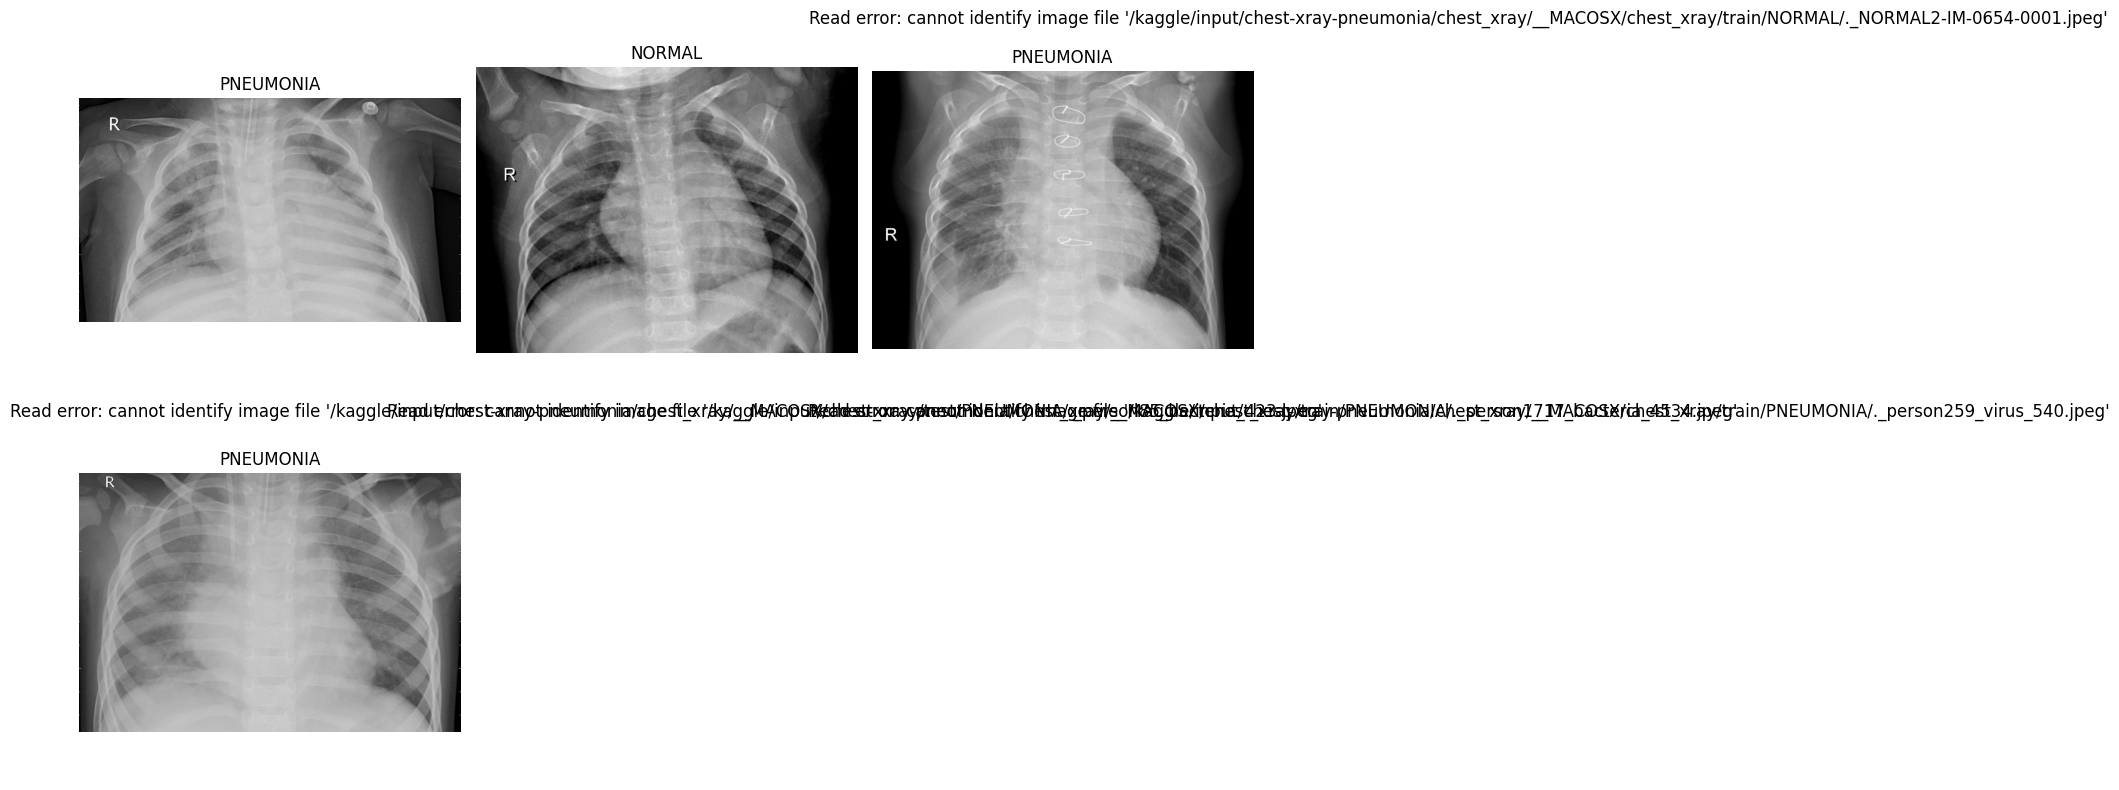

Sample width range: 428 to 2752
Sample height range: 172 to 2713


In [ ]:
# ============================================================
# C2. Image Inventory + EDA
# ============================================================
if image_available:
    image_records = []

    for root, dirs, files in os.walk(IMAGE_ROOT):
        for filename in files:
            if filename.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp")
            ):
                path = os.path.join(root, filename)
                relative = os.path.relpath(path, IMAGE_ROOT)
                parts = relative.split(os.sep)
                label = parts[-2] if len(parts) >= 2 else "UNKNOWN"
                image_records.append((path, label))

    img_df = pd.DataFrame(
        image_records,
        columns=["Path", "Label"]
    )

    print("Total images:", len(img_df))
    display(
        img_df["Label"]
        .value_counts()
        .rename_axis("Label")
        .to_frame("Count")
    )

    if len(img_df) > 0:
        sample = img_df.sample(
            min(8, len(img_df)),
            random_state=42
        ).reset_index(drop=True)

        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        axes = axes.ravel()

        for ax, (_, row) in zip(axes, sample.iterrows()):
            try:
                with Image.open(row["Path"]) as im:
                    ax.imshow(im.convert("L"), cmap="gray")
                ax.set_title(row["Label"])
            except Exception as exc:
                ax.set_title(f"Read error: {exc}")
            ax.axis("off")

        for ax in axes[len(sample):]:
            ax.axis("off")

        plt.tight_layout()
        plt.show()

        sizes = []
        for path in img_df["Path"].head(1000):
            try:
                with Image.open(path) as im:
                    sizes.append(im.size)
            except Exception:
                pass

        if sizes:
            widths, heights = zip(*sizes)
            print("Sample width range:", min(widths), "to", max(widths))
            print("Sample height range:", min(heights), "to", max(heights))
else:
    img_df = pd.DataFrame(columns=["Path", "Label"])

In [ ]:
# ============================================================
# C3. Image Cleaning + Metadata Anonymization
# ============================================================

if image_available and len(img_df) > 0:

    print("Total images found:", len(img_df))

    # Check a representative sample for metadata.
    sample_paths = img_df["Path"].head(20).tolist()

    metadata_entries = []
    readable = 0

    for path in sample_paths:
        try:
            with Image.open(path) as im:
                metadata_entries.append(len(im.getexif()))
                readable += 1
        except Exception:
            pass

    print("Readable sample images:", readable)

    if metadata_entries:
        print(
            "EXIF entries found in sample:",
            sum(metadata_entries)
        )
    else:
        print("No EXIF metadata detected in sampled images.")

    # The dataset is not modified in-place.
    # For privacy-safe preprocessing, images are opened with PIL and
    # converted to pixel arrays later in C4. Pixel arrays contain
    # image data only and do not carry JPEG/EXIF metadata.
    #
    # We therefore avoid creating thousands of duplicate PNG files.

    clean_df = img_df.copy()

    print("Image metadata handling completed.")
    print("No duplicate image files were created.")
    print("Images will be read as pixel arrays during preprocessing.")

else:
    clean_df = pd.DataFrame(columns=["Path", "Label"])
    print("Image dataset is not available.")

Total images found: 17568
Readable sample images: 20
EXIF entries found in sample: 86
Image metadata handling completed.
No duplicate image files were created.
Images will be read as pixel arrays during preprocessing.


Total candidate images: 11712
Valid images: 11712
Invalid/unreadable images removed: 0

Class distribution:


,Count
Class,
PNEUMONIA,8546
NORMAL,3166



Dataset split:
Training   : 9369
Validation : 1171
Testing    : 1172

Example image:
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person38_bacteria_195.jpeg

Original tensor shape: (1, 224, 224)
Augmented tensor shape: (1, 224, 224)
Pixel minimum: 0.0
Pixel maximum: 0.9137255


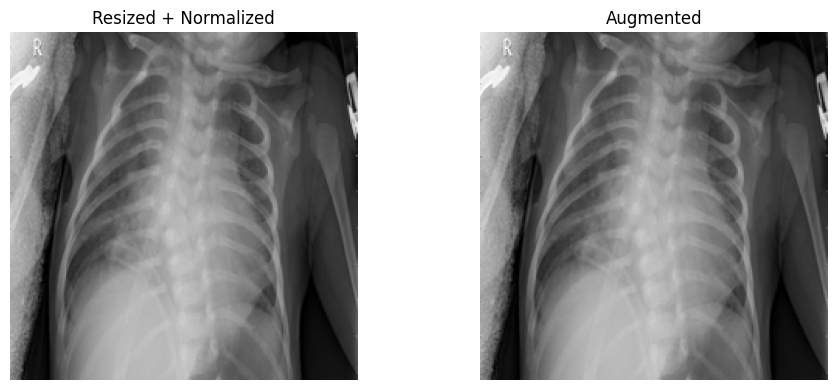

In [ ]:
# ============================================================
# C4. Image Preprocessing + Train/Validation/Test Split
#     + Model-Ready Tensor + Augmentation
# ============================================================

from PIL import Image, UnidentifiedImageError
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split


# ------------------------------------------------------------
# 1. Image dimensions
# ------------------------------------------------------------

IMG_HEIGHT = 224
IMG_WIDTH = 224


# ------------------------------------------------------------
# 2. Find valid image files
# ------------------------------------------------------------

image_records = []

for root, dirs, files in os.walk(IMAGE_ROOT):

    # Ignore macOS metadata folders
    dirs[:] = [
        d for d in dirs
        if d != "__MACOSX"
    ]

    for filename in files:

        # Ignore AppleDouble metadata files
        if filename.startswith("._"):
            continue

        # Only accept common image formats
        if not filename.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp")
        ):
            continue

        path = os.path.join(
            root,
            filename
        )

        # The parent directory should contain the class name
        label = os.path.basename(root)

        # Keep only the two assigned classes
        if label.upper() not in [
            "NORMAL",
            "PNEUMONIA"
        ]:
            continue

        image_records.append(
            (path, label.upper())
        )


# Create dataframe
img_df = pd.DataFrame(
    image_records,
    columns=["Path", "Label"]
)


print("Total candidate images:", len(img_df))


# ------------------------------------------------------------
# 3. Validate images
# ------------------------------------------------------------

valid_records = []
invalid_count = 0

for path, label in img_df.itertuples(
    index=False,
    name=None
):

    try:

        with Image.open(path) as image:
            image.verify()

        valid_records.append(
            (path, label)
        )

    except (
        UnidentifiedImageError,
        OSError,
        ValueError
    ):

        invalid_count += 1


# Rebuild dataframe using only valid images
img_df = pd.DataFrame(
    valid_records,
    columns=["Path", "Label"]
)


print("Valid images:", len(img_df))
print("Invalid/unreadable images removed:", invalid_count)


# ------------------------------------------------------------
# 4. Display class distribution
# ------------------------------------------------------------

if len(img_df) > 0:

    print("\nClass distribution:")

    class_distribution = (
        img_df["Label"]
        .value_counts()
        .rename_axis("Class")
        .to_frame("Count")
    )

    display(class_distribution)


# ------------------------------------------------------------
# 5. Train / Validation / Test split
# ------------------------------------------------------------

if len(img_df) > 0:

    try:

        # 80% training, 20% temporary
        train_df, temp_df = train_test_split(
            img_df,
            test_size=0.20,
            stratify=img_df["Label"],
            random_state=42
        )

        # Split remaining 20% equally:
        # 10% validation + 10% test
        val_df, test_df = train_test_split(
            temp_df,
            test_size=0.50,
            stratify=temp_df["Label"],
            random_state=42
        )

    except ValueError as e:

        print(
            "Stratified split failed:",
            e
        )

        print(
            "Using random split instead."
        )

        train_df, temp_df = train_test_split(
            img_df,
            test_size=0.20,
            random_state=42
        )

        val_df, test_df = train_test_split(
            temp_df,
            test_size=0.50,
            random_state=42
        )


    print("\nDataset split:")
    print(
        "Training   :",
        len(train_df)
    )
    print(
        "Validation :",
        len(val_df)
    )
    print(
        "Testing    :",
        len(test_df)
    )


# ------------------------------------------------------------
# 6. Image → Model-ready tensor
# ------------------------------------------------------------

def resize_normalize_image(path):

    with Image.open(path) as image:

        # Convert X-ray to grayscale
        image = image.convert("L")

        # Resize to standard dimensions
        image = image.resize(
            (IMG_WIDTH, IMG_HEIGHT)
        )

        # Convert to NumPy array
        array = np.asarray(
            image,
            dtype=np.float32
        )

    # Normalize pixel values
    # Original range: 0–255
    # New range: 0–1
    array = array / 255.0

    # Add channel dimension
    #
    # Before:
    # (224, 224)
    #
    # After:
    # (1, 224, 224)
    tensor = array[
        np.newaxis,
        :,
        :
    ]

    return tensor


# ------------------------------------------------------------
# 7. Image augmentation
# ------------------------------------------------------------

def augment_image_tensor(
    tensor,
    rng=None
):

    if rng is None:

        rng = np.random.default_rng(
            42
        )

    augmented = tensor.copy()


    # Random horizontal flip
    if rng.random() < 0.5:

        augmented = augmented[
            :,
            :,
            ::-1
        ]


    # Small brightness/intensity variation
    brightness = rng.uniform(
        0.95,
        1.05
    )

    augmented = (
        augmented * brightness
    )


    # Keep pixel values between 0 and 1
    augmented = np.clip(
        augmented,
        0.0,
        1.0
    )


    return augmented.astype(
        np.float32
    )


# ------------------------------------------------------------
# 8. Process one example image
# ------------------------------------------------------------

if len(train_df) > 0:

    example_path = None

    # Find first image that can actually be processed
    for path in train_df["Path"]:

        try:

            test_tensor = resize_normalize_image(
                path
            )

            example_path = path
            break

        except (
            UnidentifiedImageError,
            OSError,
            ValueError
        ):

            continue


    if example_path is None:

        print(
            "ERROR: No readable image was found."
        )

    else:

        # -----------------------------------------------
        # Original model-ready tensor
        # -----------------------------------------------

        example_tensor = resize_normalize_image(
            example_path
        )


        # -----------------------------------------------
        # Augmented tensor
        # -----------------------------------------------

        augmented_tensor = augment_image_tensor(
            example_tensor
        )


        # -----------------------------------------------
        # Display information
        # -----------------------------------------------

        print(
            "\nExample image:"
        )

        print(
            example_path
        )

        print(
            "\nOriginal tensor shape:",
            example_tensor.shape
        )

        print(
            "Augmented tensor shape:",
            augmented_tensor.shape
        )

        print(
            "Pixel minimum:",
            example_tensor.min()
        )

        print(
            "Pixel maximum:",
            example_tensor.max()
        )


        # -----------------------------------------------
        # Display images
        # -----------------------------------------------

        plt.figure(
            figsize=(10, 4)
        )


        # Original
        plt.subplot(
            1,
            2,
            1
        )

        plt.imshow(
            example_tensor[0],
            cmap="gray"
        )

        plt.title(
            "Resized + Normalized"
        )

        plt.axis("off")


        # Augmented
        plt.subplot(
            1,
            2,
            2
        )

        plt.imshow(
            augmented_tensor[0],
            cmap="gray"
        )

        plt.title(
            "Augmented"
        )

        plt.axis("off")


        plt.tight_layout()
        plt.show()


else:

    print(
        "No valid images found."
    )

In [ ]:
# ============================================================
# C5. Image Feature Extraction — HOG
#     Robust version: skips corrupted / metadata files
# ============================================================

from PIL import Image, UnidentifiedImageError
from skimage.feature import hog
from sklearn.feature_selection import VarianceThreshold
import numpy as np
import os


def extract_hog(path):

    try:

        # Open image
        with Image.open(path) as im:

            # Force actual image decoding
            im.load()

            # Convert to grayscale
            gray = im.convert("L")

            # Resize
            gray = gray.resize(
                (IMG_WIDTH, IMG_HEIGHT)
            )

            # Convert to NumPy
            arr = np.asarray(
                gray,
                dtype=np.float32
            ) / 255.0

        # HOG feature extraction
        features = hog(
            arr,
            orientations=9,
            pixels_per_cell=(16, 16),
            cells_per_block=(2, 2),
            block_norm="L2-Hys"
        )

        return features

    except (
        UnidentifiedImageError,
        OSError,
        ValueError
    ) as e:

        print(
            "Skipping invalid image:",
            path
        )

        return None


# ------------------------------------------------------------
# Select images
# ------------------------------------------------------------

if len(train_df) > 0:

    # Use a manageable sample for feature extraction.
    # Increase this if your system is fast enough.
    MAX_HOG_IMAGES = min(
        200,
        len(train_df)
    )

    hog_paths = train_df["Path"].head(
        MAX_HOG_IMAGES
    ).tolist()

    print(
        "Attempting HOG extraction on",
        len(hog_paths),
        "images..."
    )


    # --------------------------------------------------------
    # Extract features safely
    # --------------------------------------------------------

    valid_features = []
    valid_paths = []

    for i, path in enumerate(hog_paths):

        # Explicitly ignore macOS metadata
        if (
            "__MACOSX" in path
            or os.path.basename(path).startswith("._")
        ):
            print(
                "Skipping macOS metadata file:",
                path
            )
            continue

        features = extract_hog(path)

        if features is not None:

            valid_features.append(
                features
            )

            valid_paths.append(
                path
            )

        # Progress
        if (i + 1) % 25 == 0:

            print(
                f"Processed {i + 1}/{len(hog_paths)}"
            )


    # --------------------------------------------------------
    # Convert to feature matrix
    # --------------------------------------------------------

    if len(valid_features) > 0:

        hog_features = np.vstack(
            valid_features
        )

        print(
            "\nValid images:",
            len(valid_features)
        )

        print(
            "HOG feature matrix:",
            hog_features.shape
        )


        # ----------------------------------------------------
        # Remove zero-variance features
        # ----------------------------------------------------

        vt_hog = VarianceThreshold(
            threshold=0.0
        )

        hog_reduced = vt_hog.fit_transform(
            hog_features
        )

        print(
            "After zero-variance feature removal:",
            hog_reduced.shape
        )

        print(
            "HOG feature extraction completed successfully."
        )

    else:

        hog_features = np.empty(
            (0, 0)
        )

        hog_reduced = np.empty(
            (0, 0)
        )

        print(
            "No valid images were available for HOG extraction."
        )

else:

    hog_features = np.empty(
        (0, 0)
    )

    hog_reduced = np.empty(
        (0, 0)
    )

    print(
        "Training dataset is empty."
    )

Attempting HOG extraction on 200 images...
Processed 25/200
Processed 50/200
Processed 75/200
Processed 100/200
Processed 125/200
Processed 150/200
Processed 175/200
Processed 200/200

Valid images: 200
HOG feature matrix: (200, 6084)
After zero-variance feature removal: (200, 6084)
HOG feature extraction completed successfully.


In [ ]:
# ============================================================
# C6. Image Class Imbalance Check
# ============================================================
if len(train_df) > 0:
    class_counts = train_df["Label"].value_counts()

    class_weights_img = (
        len(train_df)
        / (len(class_counts) * class_counts)
    ).to_dict()

    print("Training class counts:")
    display(class_counts.to_frame("Count"))

    print("Suggested inverse-frequency class weights:")
    print(class_weights_img)

Training class counts:


,Count
Label,
PNEUMONIA,6836
NORMAL,2533


Suggested inverse-frequency class weights:
{'PNEUMONIA': 0.6852691632533645, 'NORMAL': 1.8493880773786024}


### Image preprocessing summary
- **Cleaning:** unreadable files are skipped and pixel data are re-saved as PNG to avoid carrying common EXIF metadata.
- **Preprocessing:** resize to 224×224 and normalize intensities to [0, 1].
- **Feature extraction:** HOG descriptors.
- **Feature selection:** zero-variance removal.
- **Augmentation:** horizontal flip and small intensity scaling.
- **Imbalance:** class frequencies and inverse-frequency weights are calculated.

# PART D — SIGNAL DATA
## MIT-BIH Arrhythmia Database (ECG)

The MIT-BIH Arrhythmia Database contains 48 half-hour, two-channel ambulatory ECG excerpts from 47 subjects. The recordings were digitized at 360 samples/second/channel and include reference beat annotations. citeturn0search8turn0search4

In [ ]:
# ============================================================
# D1. Acquire MIT-BIH Record 100
# ============================================================
if importlib.util.find_spec("wfdb") is None:
    print("Installing wfdb...")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "wfdb"]
    )

import wfdb

MITDB_DIR = "mitdb"
os.makedirs(MITDB_DIR, exist_ok=True)

try:
    record = wfdb.rdrecord("100", pn_dir="mitdb")
    annotation = wfdb.rdann("100", "atr", pn_dir="mitdb")

    print("Signal shape:", record.p_signal.shape)
    print("Sampling frequency:", record.fs, "Hz")
    print("Channels:", record.sig_name)
    print("Number of annotations:", len(annotation.sample))
    print("First annotation symbols:", annotation.symbol[:20])
    signal_available = True
except Exception as exc:
    print("MIT-BIH download/read failed:", exc)
    print(
        "The signal section requires internet access or a local MIT-BIH "
        "record 100 (.hea/.dat/.atr) installation."
    )
    signal_available = False

Installing wfdb...
Signal shape: (650000, 2)
Sampling frequency: 360 Hz
Channels: ['MLII', 'V5']
Number of annotations: 2274
First annotation symbols: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


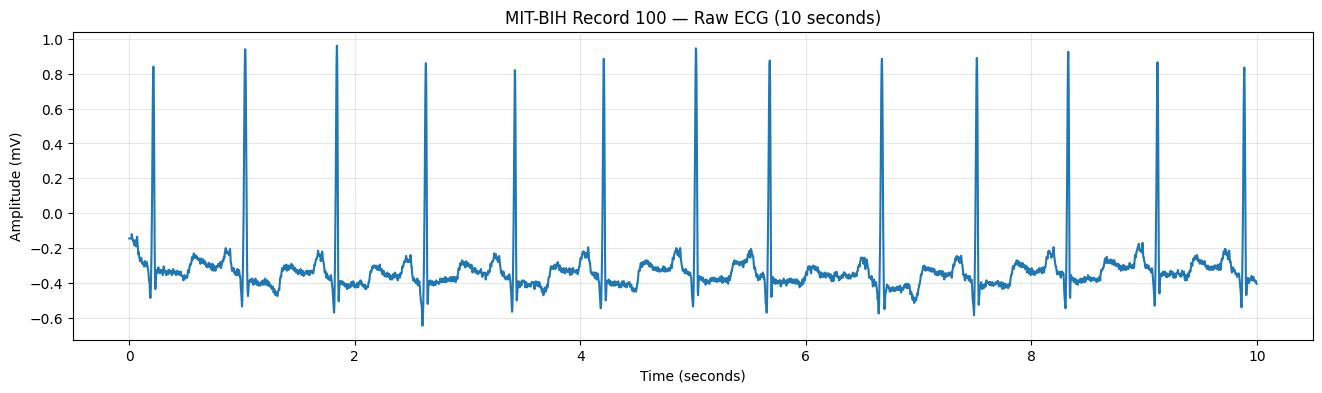

Raw ECG statistics:


,Value
count,650000.000000
mean,-0.306299
std,0.193200
min,-2.715000
25%,-0.390000
50%,-0.335000
75%,-0.270000
max,1.435000


In [ ]:
# ============================================================
# D2. Signal EDA — Raw ECG
# ============================================================
if signal_available:
    fs = float(record.fs)
    ecg = record.p_signal[:, 0]
    time = np.arange(len(ecg)) / fs

    duration_sec = 10
    n = min(int(duration_sec * fs), len(ecg))

    plt.figure(figsize=(16, 4))
    plt.plot(time[:n], ecg[:n])
    plt.title("MIT-BIH Record 100 — Raw ECG (10 seconds)")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude (mV)")
    plt.grid(True, alpha=0.3)
    plt.show()

    print("Raw ECG statistics:")
    display(pd.Series(ecg).describe().to_frame("Value"))

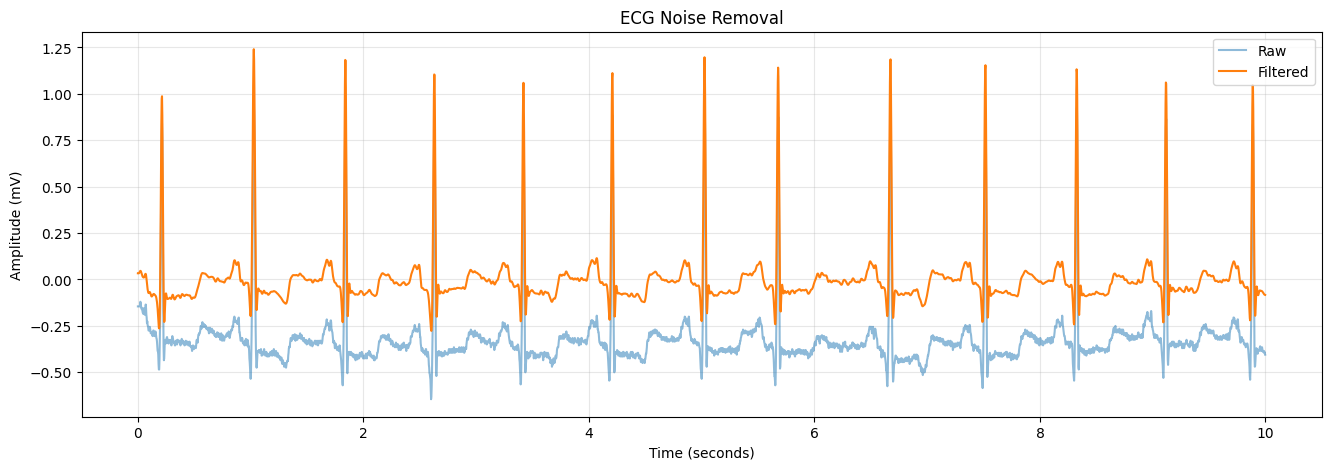

In [ ]:
# ============================================================
# D3. Noise Removal — Band-pass + Notch Filter
# ============================================================
def butter_bandpass_filter(x, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = signal.butter(
        order,
        [low, high],
        btype="band"
    )
    return signal.filtfilt(b, a, x)

def notch_filter(x, notch_hz, fs, quality=30):
    # Only apply if the notch frequency is below Nyquist.
    if notch_hz >= fs / 2:
        return x

    b, a = signal.iirnotch(
        notch_hz,
        quality,
        fs=fs
    )
    return signal.filtfilt(b, a, x)

if signal_available:
    ecg_filtered = butter_bandpass_filter(
        ecg,
        lowcut=0.5,
        highcut=40.0,
        fs=fs,
        order=4
    )

    # 50 Hz is the common power-line frequency in many regions.
    ecg_filtered = notch_filter(
        ecg_filtered,
        notch_hz=50.0,
        fs=fs,
        quality=30
    )

    plt.figure(figsize=(16, 5))
    plt.plot(
        time[:n],
        ecg[:n],
        alpha=0.5,
        label="Raw"
    )
    plt.plot(
        time[:n],
        ecg_filtered[:n],
        label="Filtered"
    )
    plt.title("ECG Noise Removal")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude (mV)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
# ============================================================
# D4. Beat-Centered Signal Windows
# ============================================================
AAMI_GROUPS = {
    "N": {"N", "L", "R", "e", "j"},
    "S": {"A", "a", "J", "S"},
    "V": {"V", "E"},
    "F": {"F"},
    "Q": {"/", "f", "Q"}
}

symbol_to_group = {}
for group, symbols in AAMI_GROUPS.items():
    for symbol in symbols:
        symbol_to_group[symbol] = group

if signal_available:
    WINDOW_PRE = int(0.25 * fs)
    WINDOW_POST = int(0.45 * fs)

    windows = []
    labels = []

    for sample_idx, symbol in zip(
        annotation.sample,
        annotation.symbol
    ):
        if symbol not in symbol_to_group:
            continue

        start = int(sample_idx) - WINDOW_PRE
        end = int(sample_idx) + WINDOW_POST

        if start >= 0 and end <= len(ecg_filtered):
            windows.append(
                ecg_filtered[start:end]
            )
            labels.append(
                symbol_to_group[symbol]
            )

    X_ecg = np.asarray(
        windows,
        dtype=np.float32
    )
    y_ecg = np.asarray(labels)

    print("Signal-window matrix:", X_ecg.shape)
    display(
        pd.Series(y_ecg)
        .value_counts()
        .rename_axis("Class")
        .to_frame("Count")
    )
else:
    X_ecg = np.empty((0, 0), dtype=np.float32)
    y_ecg = np.array([])

Signal-window matrix: (2271, 252)


,Count
Class,
N,2237
S,33
V,1


In [ ]:
# ============================================================
# D5. ECG Feature Engineering
# ============================================================
def ecg_features(window):
    return [
        np.mean(window),
        np.std(window),
        np.min(window),
        np.max(window),
        np.ptp(window),
        np.percentile(window, 25),
        np.median(window),
        np.percentile(window, 75),
        np.sqrt(np.mean(window ** 2)),
    ]

feature_names = [
    "mean",
    "std",
    "min",
    "max",
    "peak_to_peak",
    "q25",
    "median",
    "q75",
    "RMS"
]

if len(X_ecg) > 0:
    X_ecg_features = np.asarray(
        [ecg_features(w) for w in X_ecg],
        dtype=np.float32
    )

    ecg_feature_df = pd.DataFrame(
        X_ecg_features,
        columns=feature_names
    )

    display(ecg_feature_df.describe().T)
else:
    X_ecg_features = np.empty(
        (0, len(feature_names)),
        dtype=np.float32
    )

,count,mean,std,min,25%,50%,75%,max
mean,2271.0,0.001715,0.009268,-0.137718,-0.003699,0.001929,0.007383,0.094502
std,2271.0,0.192875,0.025216,0.136526,0.175811,0.189802,0.204916,0.710718
min,2271.0,-0.242851,0.051132,-2.458847,-0.253093,-0.241079,-0.228784,-0.158695
max,2271.0,1.228622,0.123439,0.867978,1.132845,1.220296,1.311519,1.693509
peak_to_peak,2271.0,1.471473,0.131811,1.038867,1.375487,1.458843,1.553330,3.631030
q25,2271.0,-0.083742,0.015459,-0.284716,-0.093553,-0.083257,-0.073793,0.034192
median,2271.0,-0.033349,0.011542,-0.177340,-0.040611,-0.033519,-0.025806,0.056708
q75,2271.0,0.026957,0.014343,-0.050604,0.020162,0.026573,0.033067,0.487274
RMS,2271.0,0.193092,0.025316,0.136534,0.175840,0.189996,0.205063,0.714866


In [ ]:
# ============================================================
# D6. ECG Feature Selection + Model-Ready Scaling
# ============================================================
if len(X_ecg_features) > 0:
    valid_mask = np.isfinite(
        X_ecg_features
    ).all(axis=1)

    Xf = X_ecg_features[valid_mask]
    yf = y_ecg[valid_mask]

    if len(np.unique(yf)) >= 2:
        vt_ecg = VarianceThreshold(
            threshold=0.0
        )
        Xf_v = vt_ecg.fit_transform(Xf)

        kept_names = np.array(feature_names)[
            vt_ecg.get_support()
        ]

        le_ecg = LabelEncoder()
        y_encoded = le_ecg.fit_transform(yf)

        k = min(6, Xf_v.shape[1])
        ecg_selector = SelectKBest(
            score_func=f_classif,
            k=k
        )
        Xf_sel = ecg_selector.fit_transform(
            Xf_v,
            y_encoded
        )

        selected_ecg_names = kept_names[
            ecg_selector.get_support()
        ]

        scaler_ecg = StandardScaler()
        X_ecg_scaled = scaler_ecg.fit_transform(
            Xf_sel
        )

        print(
            "Selected ECG features:",
            list(selected_ecg_names)
        )
        print(
            "Model-ready ECG feature matrix:",
            X_ecg_scaled.shape
        )
    else:
        X_ecg_scaled = Xf
        print("Only one ECG class was available; supervised selection skipped.")
else:
    X_ecg_scaled = np.empty((0, len(feature_names)))

Selected ECG features: [np.str_('mean'), np.str_('std'), np.str_('min'), np.str_('peak_to_peak'), np.str_('q75'), np.str_('RMS')]
Model-ready ECG feature matrix: (2271, 6)


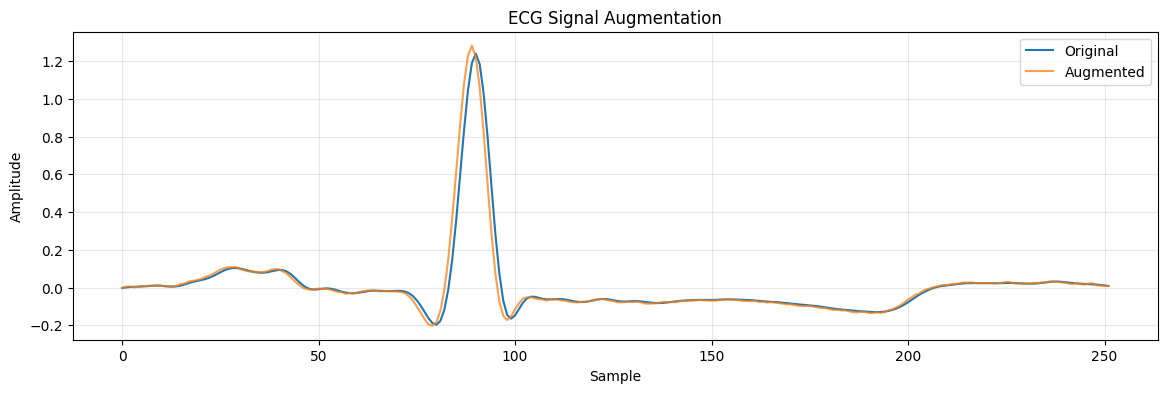

In [ ]:
# ============================================================
# D7. ECG Signal Augmentation
# ============================================================
rng = np.random.default_rng(42)

def augment_ecg(
    window,
    noise_std=0.01,
    scale_range=(0.95, 1.05),
    max_shift=3
):
    noisy = (
        window
        + rng.normal(
            0,
            noise_std * max(np.std(window), 1e-8),
            size=window.shape
        )
    )

    scale = rng.uniform(*scale_range)
    noisy = noisy * scale

    shift = int(
        rng.integers(
            -max_shift,
            max_shift + 1
        )
    )

    if shift > 0:
        noisy = np.pad(
            noisy[:-shift],
            (shift, 0),
            mode="edge"
        )
    elif shift < 0:
        s = abs(shift)
        noisy = np.pad(
            noisy[s:],
            (0, s),
            mode="edge"
        )

    return noisy.astype(np.float32)

if len(X_ecg) > 0:
    augmented_example = augment_ecg(
        X_ecg[0]
    )

    plt.figure(figsize=(14, 4))
    plt.plot(
        X_ecg[0],
        label="Original"
    )
    plt.plot(
        augmented_example,
        label="Augmented",
        alpha=0.75
    )
    plt.title("ECG Signal Augmentation")
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
# ============================================================
# D8. ECG Windows as Deep-Learning Input
# ============================================================
if len(X_ecg) > 0:
    # Shape: (samples, time, channels)
    X_ecg_tensor = X_ecg[:, :, np.newaxis]

    window_mean = X_ecg_tensor.mean(
        axis=1,
        keepdims=True
    )
    window_std = (
        X_ecg_tensor.std(
            axis=1,
            keepdims=True
        ) + 1e-8
    )

    X_ecg_tensor_norm = (
        X_ecg_tensor - window_mean
    ) / window_std

    print(
        "Model-ready ECG tensor:",
        X_ecg_tensor_norm.shape
    )
    print(
        "Expected 1-D CNN format:",
        "(batch, time, channels)"
    )
else:
    X_ecg_tensor_norm = np.empty(
        (0, 0, 1),
        dtype=np.float32
    )

Model-ready ECG tensor: (2271, 252, 1)
Expected 1-D CNN format: (batch, time, channels)
